<div style="background-color: #e8f5e9; border-left: 6px solid #2e7d32; padding: 15px; margin-bottom: 20px; border-radius: 4px;">
    <h1 style="color: #1b5e20; margin: 0; font-family: sans-serif;">Exploratory Data Analysis (EDA) & Spectral Separability</h1>
    <p style="margin: 5px 0 0 0; color: #37474f; font-size: 1.1em;">
        Descriptive statistics, multi-sensor spectral signature profiling, and ANOVA/Tukey HSD separability analysis.
    </p>
</div>

In [1]:
# 1. Standard Library Imports
import os
import gc
import math
import json
from pathlib import Path
from itertools import combinations
import xml.etree.ElementTree as ET

# 2. Third-Party Scientific & Data Processing Imports
import cv2
import openpyxl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
from scipy.spatial import distance
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 3. GIS & Geospatial Analysis Imports
import fiona
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
from rasterio.plot import show, reshape_as_image
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats

# 4. Machine Learning & Model Evaluation Imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    balanced_accuracy_score, recall_score
)
from skimage.feature import graycomatrix, graycoprops
from skimage.registration import phase_cross_correlation

# 5. Environment & Output Visualization Configuration
import warnings
import nest_asyncio
import dataframe_image as dfi

# System overrides & setups
warnings.filterwarnings('ignore')
nest_asyncio.apply()
fiona.drvsupport.supported_drivers['KML'] = 'rw'

c:\Users\48755625H\AppData\Local\anaconda3\envs\esa-project-1\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [2]:
#BASE
path_base = Path(os.getcwd()).parent
#SHAPEFILES
shp_pln = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_PlnScope_EPSG32630.shp"
shp_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_wv-02_EsquinaII_EPSG32630.shp"
shp_bounds = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot.shp"
shp_bounds_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot_wv2.shp"
#RASTER-IMAGERY
ortho_path = Path(path_base) / "01_img_data/drone/DJI Matrice 300 RTK/2024-06-13_MaízPoveda_RGB_20m_Orthomosaic.tif"
out_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_BOA.tif"
out_pan_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-P3DS-050518203010_01_P001_BOA.TIF"
out_ms_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA.TIF"
#PANSHARPENING
pansharp_BROV = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_brovey.TIF"
pansharp_MEAN = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_mean.TIF"
pansharp_ESRI = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_esri.TIF"
pansharp_GS = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_gram_schmidt.TIF"
#DATASETS-RODALES
path_dfA = Path(path_base) / "07_datasets/Dataset_1_Planet_3m.xlsx"
path_dfB = Path(path_base) / "07_datasets/Dataset_2_WV2_MS_2m.xlsx"
path_dfC = Path(path_base) / "07_datasets/Dataset_3_WV2_Pansharp_GS_05m.xlsx"

**Comparison of centre-point pixels and edge pixels included in the spectral mean calculation for each patch by size**

In [3]:
def count_patch_pixels(geom, src):
    """
    Calculates how many pixels contribute to the mean (centroid inside) 
    and how many are edge-only pixels (touched but centroid outside).
    """
    res = src.res[0]
    minx, miny, maxx, maxy = geom.bounds
    window = from_bounds(minx - res, miny - res, maxx + res, maxy + res, src.transform)
    window = window.round_lengths().round_offsets()
    win_transform = src.window_transform(window)
    out_shape = (window.height, window.width)
    if out_shape[0] <= 0 or out_shape[1] <= 0:
        return 0, 0
        
    # Mask 1: Only pixels whose center falls INSIDE the polygon (all_touched=False)
    center_mask = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=False, invert=True )
    # Mask 2: ALL pixels that are touched by the polygon (all_touched=True)
    touched_mask = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=True, invert=True)
    center_pixels = center_mask.sum()
    total_pixels = touched_mask.sum()
    edge_pixels = total_pixels - center_pixels
    return center_pixels, edge_pixels

def analyze_pixel_coverage(image_dict, col_class='Patch_size'):
    """
    Iterates over the images and their corresponding shapefiles to calculate
    the mean area and pixel distribution per class.
    """
    total_results = []
    
    for name, config in image_dict.items():
        raster_path = config['raster']
        shp_path = config['shp']
        gdf = gpd.read_file(shp_path)
        gdf['Area_m2'] = gdf.geometry.area
        with rasterio.open(raster_path) as src:
            counts = gdf.geometry.apply(lambda g: count_patch_pixels(g, src))
            gdf['Px_Center (Useful)'] = [c[0] for c in counts]
            gdf['Px_Edge (Discarded)'] = [c[1] for c in counts]
        summary = gdf.groupby(col_class).agg({
            'Area_m2': 'mean',
            'Px_Center (Useful)': 'mean',
            'Px_Edge (Discarded)': 'mean'
        }).reset_index()
        summary['Image'] = name
        total_results.append(summary)
    final_df = pd.concat(total_results, ignore_index=True)
    final_df = final_df[['Image', col_class, 'Area_m2', 'Px_Center (Useful)', 'Px_Edge (Discarded)']]
    return final_df.round(2)

configuration = {
    'PlanetScope MS (3m)': {
        'raster': out_pln, # Path to Planet TIF
        'shp': shp_pln   # Path to Planet SHP
    },
    'WorldView-2 MS (2m)': {
        'raster': out_ms_wv2,     # Path to original WV2 TIF
        'shp': shp_wv2   # Path to WV2 SHP
    },
    'WorldView-2 pansharp (0.5m)': {
        'raster': pansharp_GS, # Path to pansharpened TIF (Gram-Schmidt)
        'shp': shp_wv2         # WV2 shares the same SHP
    }
}

df_coverage = analyze_pixel_coverage(configuration)
logical_order = ['High', 'Medium', 'Low', 'no-sorgo']
df_coverage['Patch_size'] = pd.Categorical(
    df_coverage['Patch_size'], 
    categories=logical_order, 
    ordered=True)
df_coverage = df_coverage.sort_values(by=['Image', 'Patch_size']).reset_index(drop=True)
print("\n COVERAGE TABLE: Central vs Edge Pixels by Class")
print("-" * 80)
display(df_coverage)



 COVERAGE TABLE: Central vs Edge Pixels by Class
--------------------------------------------------------------------------------


,Image,Patch_size,Area_m2,Px_Center (Useful),Px_Edge (Discarded)
0,PlanetScope MS (3m),High,55.22,6.12,8.25
1,PlanetScope MS (3m),Medium,2.12,0.22,2.28
2,PlanetScope MS (3m),Low,0.20,0.02,1.18
3,PlanetScope MS (3m),no-sorgo,119.85,13.22,10.40
4,WorldView-2 MS (2m),High,55.22,13.91,12.19
5,WorldView-2 MS (2m),Medium,2.12,0.48,3.24
6,WorldView-2 MS (2m),Low,0.20,0.05,1.27
7,WorldView-2 MS (2m),no-sorgo,119.85,29.91,15.76
8,WorldView-2 pansharp (0.5m),High,55.22,220.62,64.14
9,WorldView-2 pansharp (0.5m),Medium,2.12,8.55,10.66


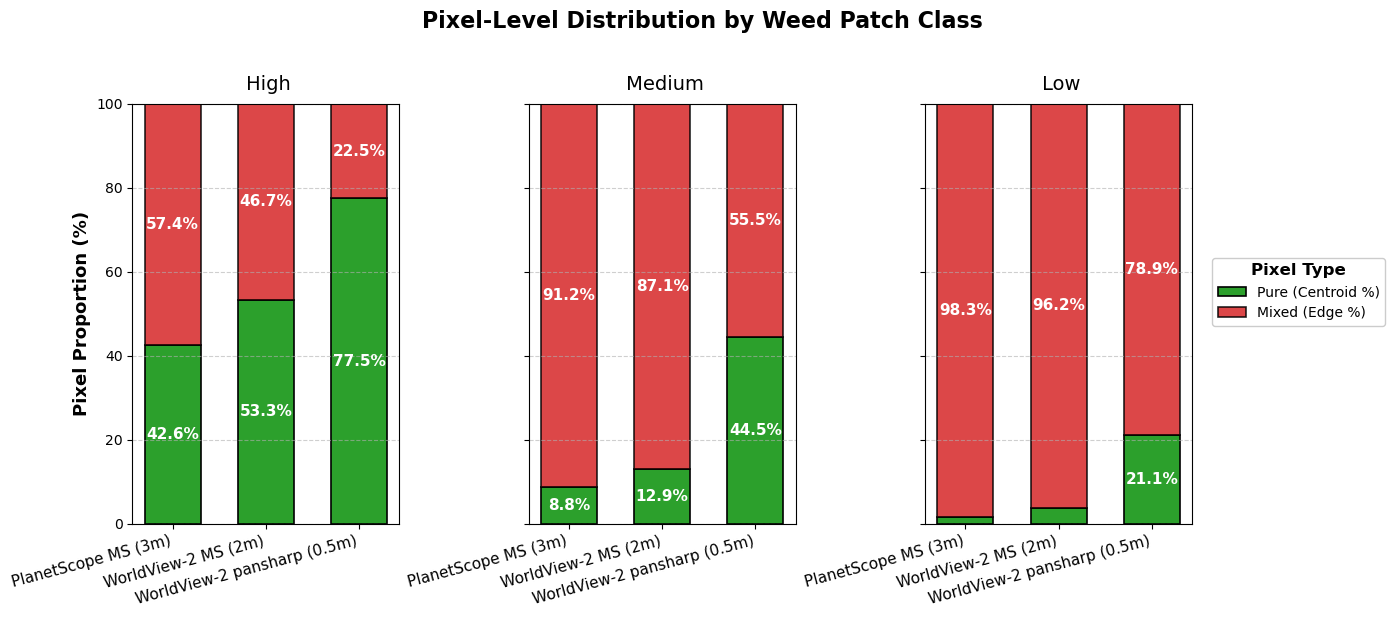

In [4]:
def plot_coverage_percentages(df_coverage, col_class='Patch_size'):
    df = df_coverage.copy()
    df['Total_Px'] = df['Px_Center (Useful)'] + df['Px_Edge (Discarded)']
    
    df['% Center (Pure)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Center (Useful)'] / df['Total_Px']) * 100, 0)
    df['% Edge (Mixed)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Edge (Discarded)'] / df['Total_Px']) * 100, 100)
    classes = [c for c in df[col_class].unique() if c != 'no-sorgo']
    images = df['Image'].unique()
    fig, axes = plt.subplots(1, len(classes), figsize=(14, 6), sharey=True)
    fig.suptitle('Pixel-Level Distribution by Weed Patch Class', 
                 fontsize=16, fontweight='bold', y=1.02)
    pure_color = '#2ca02c'   
    mixed_color = '#d62728'  
    x_pos = np.arange(len(images))
    width = 0.6
    for i, class_name in enumerate(classes):
        ax = axes[i] if len(classes) > 1 else axes
        class_data = df[df[col_class] == class_name].set_index('Image').reindex(images)
        pct_pure = class_data['% Center (Pure)'].fillna(0).values
        pct_mixed = class_data['% Edge (Mixed)'].fillna(100).values
        pure_bars = ax.bar(x_pos, pct_pure, width, label='Pure (Centroid %)', 
                           color=pure_color, edgecolor='black', linewidth=1.2)
        mixed_bars = ax.bar(x_pos, pct_mixed, width, bottom=pct_pure, label='Mixed (Edge %)', 
                            color=mixed_color, edgecolor='black', linewidth=1.2, alpha=0.85)
        for j in range(len(x_pos)):
            if pct_pure[j] > 5:
                ax.text(x_pos[j], pct_pure[j]/2, f"{pct_pure[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
            if pct_mixed[j] > 5:
                ax.text(x_pos[j], pct_pure[j] + (pct_mixed[j]/2), f"{pct_mixed[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        
        # Aesthetics
        ax.set_title(f" {class_name}", fontsize=14, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(images, rotation=15, ha='right', fontsize=11)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        if i == 0:
            ax.set_ylabel('Pixel Proportion (%)', fontsize=13, fontweight='bold')
        if pct_pure[0] == 0:
            ax.text(x_pos[0], 105, "100% Noise!", color='red', ha='center', fontsize=10, fontweight='bold')
    axes[-1].legend(title='Pixel Type', 
                    title_fontproperties={'weight':'bold', 'size':12},
                    loc='upper left', 
                    bbox_to_anchor=(1.05, 0.65), 
                    framealpha=1)
    plt.tight_layout()
    plt.show()

plot_coverage_percentages(df_coverage)

**Analisis exploratorio de los datos (EDA)**

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif; margin-bottom: 20px;">
    <thead>
        <tr style="background-color: #f1f8e9; border-bottom: 3px solid #2e7d32;">
            <th style="padding: 10px; text-align: left; color: #1b5e20; width: 20%;">Sensor / Satellite</th>
            <th style="padding: 10px; text-align: left; color: #1b5e20;">Spectral Band Configuration</th>
        </tr>
    </thead>
    <tbody>
        <!-- WorldView-2 Row -->
        <tr style="border-bottom: 1px solid #e0e0e0;">
            <td style="padding: 12px; font-weight: bold; color: #1565c0; vertical-align: middle;">
                🛰️ WorldView-2
            </td>
            <td style="padding: 12px; line-height: 1.8;">
                <span style="background-color: #e3f2fd; color: #0d47a1; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">1: Coastal Blue</span>
                <span style="background-color: #e3f2fd; color: #0d47a1; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">2: Blue</span>
                <span style="background-color: #e8f5e9; color: #1b5e20; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">3: Green</span>
                <span style="background-color: #fffde7; color: #f57f17; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">4: Yellow</span>
                <span style="background-color: #ffebee; color: #b71c1c; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">5: Red</span>
                <span style="background-color: #fbe9e7; color: #d84315; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">6: Red Edge</span>
                <span style="background-color: #f3e5f5; color: #4a148c; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">7: NIR 1</span>
                <span style="background-color: #f3e5f5; color: #4a148c; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; display: inline-block;">8: NIR 2</span>
            </td>
        </tr>
        <!-- PlanetScope Row -->
        <tr style="border-bottom: 1px solid #e0e0e0;">
            <td style="padding: 12px; font-weight: bold; color: #2e7d32; vertical-align: middle;">
                🛰️ PlanetScope
            </td>
            <td style="padding: 12px; line-height: 1.8;">
                <span style="background-color: #e3f2fd; color: #0d47a1; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">1: Coastal Blue</span>
                <span style="background-color: #e3f2fd; color: #0d47a1; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">2: Blue</span>
                <span style="background-color: #e8f5e9; color: #1b5e20; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">3: Green I</span>
                <span style="background-color: #e8f5e9; color: #1b5e20; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">4: Green II</span>
                <span style="background-color: #fffde7; color: #f57f17; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">5: Yellow</span>
                <span style="background-color: #ffebee; color: #b71c1c; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">6: Red</span>
                <span style="background-color: #fbe9e7; color: #d84315; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; margin-right: 5px; display: inline-block;">7: Red Edge</span>
                <span style="background-color: #f3e5f5; color: #4a148c; padding: 3px 6px; border-radius: 3px; font-size: 0.9em; display: inline-block;">8: NIR</span>
            </td>
        </tr>
    </tbody>
</table>


In [10]:
dfA = pd.read_excel(path_dfA)
dfB = pd.read_excel(path_dfB)
dfC = pd.read_excel(path_dfC)

In [6]:
dfC

,ID_patch,Patch_size,Area_m2,WV2_05m_GS_B1,WV2_05m_GS_B2,WV2_05m_GS_B3,WV2_05m_GS_B4,WV2_05m_GS_B5,WV2_05m_GS_B6,WV2_05m_GS_B7,WV2_05m_GS_B8,WV2_05m_GS_NDVI,WV2_05m_GS_NDRE
0,p-0001,Low,0.111,0.025835,0.046789,0.078352,0.114421,0.169036,0.193203,0.310058,0.367917,0.294353,0.232196
1,p-0002,Low,0.040,0.025788,0.047489,0.078936,0.116569,0.172883,0.194338,0.307111,0.368486,0.279646,0.224894
2,p-0003,Low,0.793,0.025555,0.047747,0.078097,0.116923,0.172681,0.190801,0.297293,0.358940,0.265146,0.218179
3,p-0004,Low,0.064,0.018062,0.035129,0.061596,0.087276,0.127857,0.192498,0.343989,0.399265,0.458055,0.282375
4,p-0005,Low,0.688,0.018189,0.034346,0.060723,0.085611,0.124563,0.190830,0.345008,0.401909,0.469461,0.287733
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,p-1877,no-sorgo,489.383,0.017641,0.033006,0.060714,0.084154,0.121310,0.183056,0.322547,0.376595,0.453383,0.275890
1877,p-1878,no-sorgo,275.455,0.021698,0.040006,0.069290,0.100723,0.149587,0.184710,0.296914,0.350233,0.329958,0.232970
1878,p-1879,no-sorgo,182.938,0.022993,0.041558,0.071889,0.104884,0.156326,0.187340,0.294793,0.347749,0.306941,0.222869
1879,p-1880,no-sorgo,212.915,0.021028,0.038512,0.067556,0.096436,0.143487,0.182215,0.294934,0.346651,0.345435,0.236235


CLASS BALANCE (TARGET VARIABLE):
   * Low       : 84.6%
   * Medium    : 9.6%
   * High      : 3.4%
   * no-sorgo  : 2.4%
-------------------------------------------------------
MULTICOLLINEARITY SCREENING (Pearson > 0.90):
Detected 2 highly correlated variables.
List: ['PS_3m_NDVI', 'PS_3m_NDRE']...
-------------------------------------------------------
 PLOTTING CORRELATION HEATMAP...


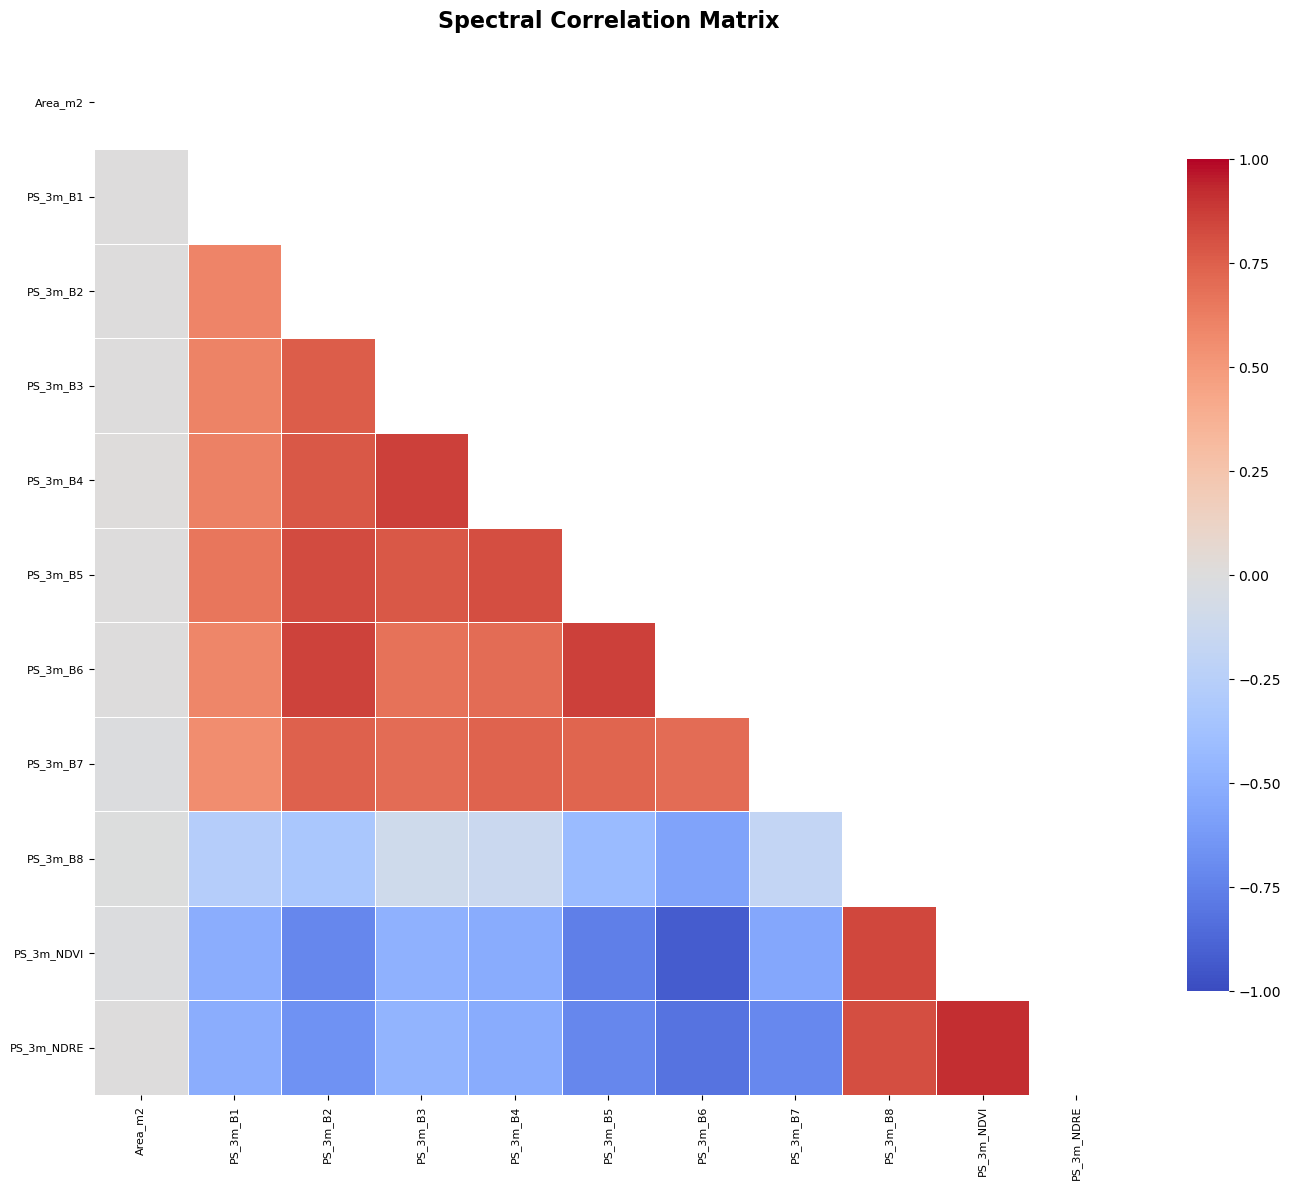


TOP FEATURE IMPORTANCE (Random Forest Classifier):
   [01] Area_m2              : 0.8170
   [02] PS_3m_B7             : 0.0247
   [03] PS_3m_B8             : 0.0220
   [04] PS_3m_NDVI           : 0.0202
   [05] PS_3m_NDRE           : 0.0188
   [06] PS_3m_B6             : 0.0178
   [07] PS_3m_B5             : 0.0176
   [08] PS_3m_B3             : 0.0176
   [09] PS_3m_B4             : 0.0154
   [10] PS_3m_B2             : 0.0147

SPECTRAL SEPARABILITY PLOTS (Top 6 Features)


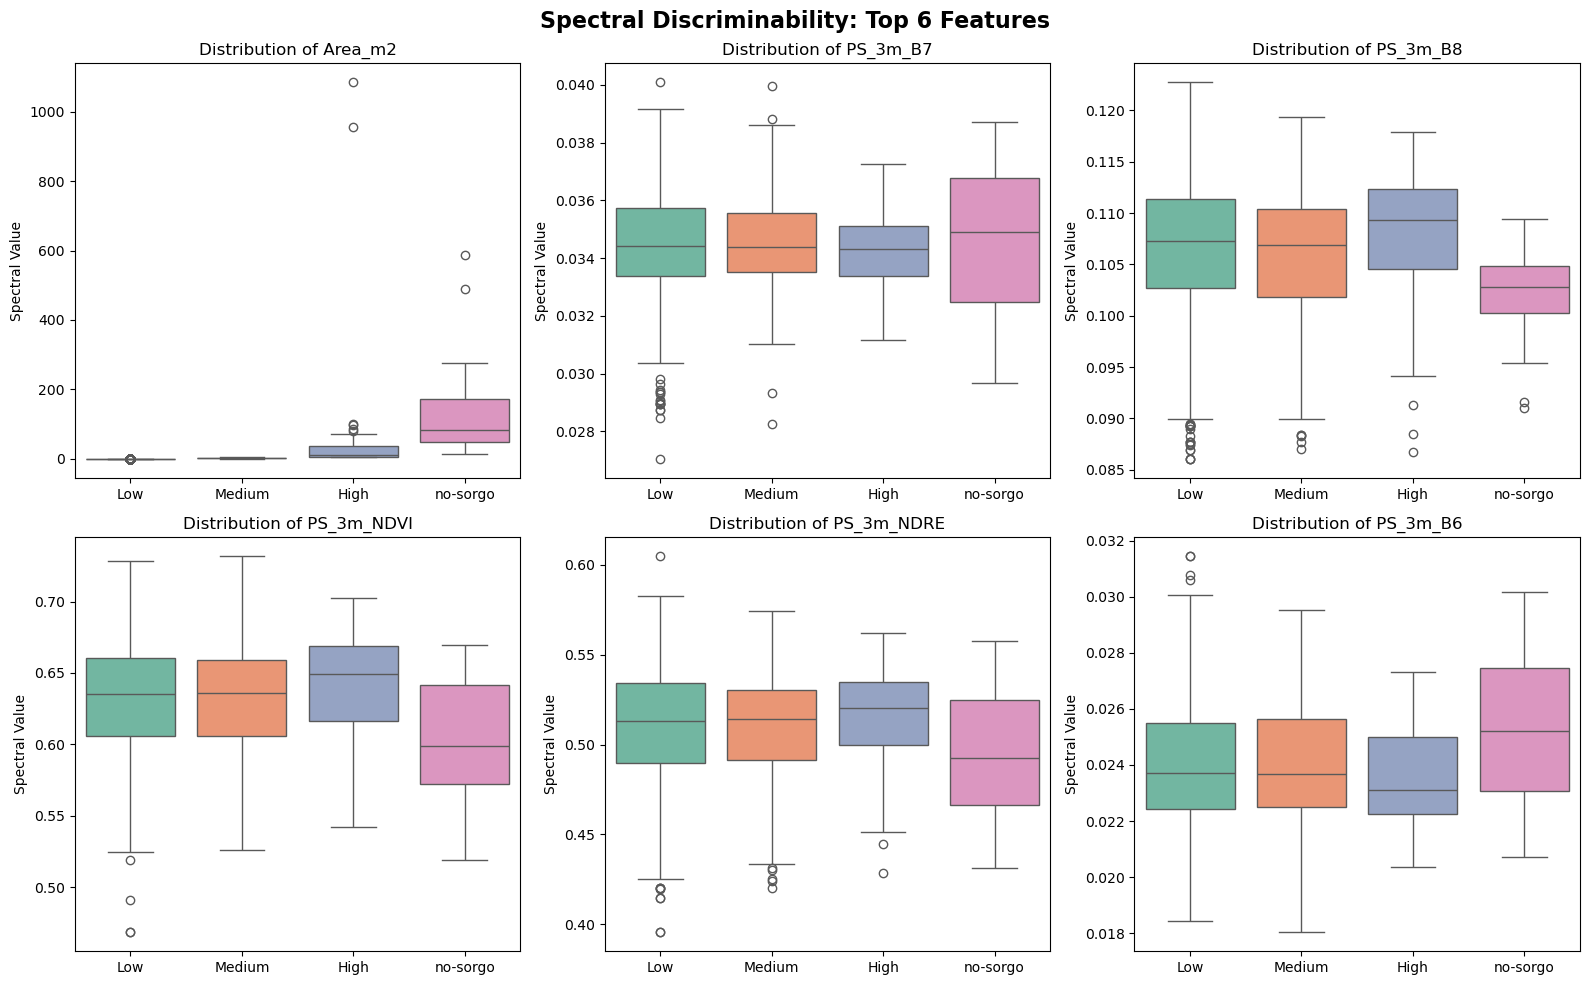

In [7]:
def run_eda(df, col_target='Patch_size'):
    X = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    y = df[col_target]
    print("CLASS BALANCE (TARGET VARIABLE):")
    class_pct = y.value_counts(normalize=True).round(3) * 100
    for cls, pct in class_pct.items():
        print(f"   * {cls:<10}: {pct:.1f}%")
    print("-" * 55)
    print("MULTICOLLINEARITY SCREENING (Pearson > 0.90):")
    corr_matrix = X.corr()
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    redundant_vars = [col for col in upper.columns if any(upper[col] > 0.90)]
    if redundant_vars:
        print(f"Detected {len(redundant_vars)} highly correlated variables.")
        print(f"List: {redundant_vars[:6]}...") 
    else:
        print("No high multicollinearity detected.")
    print("-" * 55)

    print(" PLOTTING CORRELATION HEATMAP...")
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
                annot=False, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Spectral Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(fontsize=8, rotation=90)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTOP FEATURE IMPORTANCE (Random Forest Classifier):")
    X_rf = X.fillna(0) 
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_rf, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_6_vars = importances.head(6).index
    for rank, (feature, imp) in enumerate(importances.head(10).items(), 1):
        print(f"   [{rank:02d}] {feature:<20} : {imp:.4f}")
    
    print("\nSPECTRAL SEPARABILITY PLOTS (Top 6 Features)")
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Spectral Discriminability: Top 6 Features', fontsize=16, fontweight='bold')
    for i, var in enumerate(top_6_vars):
        row, col = i // 3, i % 3
        sns.boxplot(data=df, x=col_target, y=var, ax=axes[row, col], palette='Set2')
        axes[row, col].set_title(f"Distribution of {var}")
        axes[row, col].set_xlabel("")
        axes[row, col].set_ylabel("Spectral Value")
    plt.tight_layout()
    plt.show()
#Change "df" letter to explore all datasets
run_eda(dfA, col_target='Patch_size')

In [12]:

planet_bands = {
    'B1': 'Coastal Blue\n(431-452 nm)', 'B2': 'Blue\n(465-515 nm)', 
    'B3': 'Green I\n(513-549 nm)', 'B4': 'Green II\n(547-583 nm)', 
    'B5': 'Yellow\n(600-620 nm)', 'B6': 'Red\n(650-680 nm)', 
    'B7': 'Red Edge\n(697-713 nm)', 'B8': 'NIR\n(845-885 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'}
wv2_bands = {
    'B1': 'Coastal Blue\n(400-450 nm)', 'B2': 'Blue\n(450-510 nm)', 
    'B3': 'Green\n(510-580 nm)', 'B4': 'Yellow\n(585-625 nm)', 
    'B5': 'Red\n(630-690 nm)', 'B6': 'Red Edge\n(705-745 nm)', 
    'B7': 'NIR 1\n(770-895 nm)', 'B8': 'NIR 2\n(860-1040 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'}
class_mapping = {'no-sorgo': 'Null', 'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}
class_order = ['Null', 'Low', 'Medium', 'High']

def assign_tukey_letters(df, val_col, class_col='Patch_size', alpha=0.05):
    # Get sorted means
    means = df.groupby(class_col)[val_col].mean().sort_values(ascending=False)
    sorted_classes = means.index.tolist()
    # Run Tukey HSD test
    tukey = pairwise_tukeyhsd(endog=df[val_col], groups=df[class_col], alpha=alpha)
    df_tukey = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    # Initialize letters dictionary
    letters = {cls: '' for cls in sorted_classes}
    current_letter = ord('a')
    current_groups = [[sorted_classes[0]]]
    letters[sorted_classes[0]] = chr(current_letter)
    
    for i in range(1, len(sorted_classes)):
        class_to_eval = sorted_classes[i]
        shared_group = False
        for idx, group in enumerate(current_groups):
            different_from_any = False
            for member in group:
                c1, c2 = sorted([member, class_to_eval])
                reject = df_tukey[(df_tukey['group1'] == c1) & (df_tukey['group2'] == c2)]['reject'].values[0]
                if reject:
                    different_from_any = True
                    break
            # If not significantly different from any member in the group, share the letter
            if not different_from_any:
                letters[class_to_eval] += chr(ord('a') + idx)
                group.append(class_to_eval)
                shared_group = True
        # If it is significantly different from all groups, spawn a new letter/group
        if not shared_group:
            current_letter += 1
            current_groups.append([class_to_eval])
            letters[class_to_eval] += chr(current_letter)   
    return {cls: f"{means[cls]:.4f} {letters[cls]}" for cls in sorted_classes}

def create_transposed_table(df, prefix, band_dict, class_col='Patch_size', alpha=0.001):
    spectral_cols = [c for c in df.columns if c.startswith(prefix) and c not in ['Patch_size', 'ID_patch', 'Area_m2']]
    table_data = {}
    for col in spectral_cols:
        raw_band_name = col.replace(f"{prefix}_", "")
        pub_name = band_dict.get(raw_band_name, raw_band_name)
        # Pass the alpha parameter properly to ensure correct significances
        table_data[pub_name] = assign_tukey_letters(df, col, class_col, alpha=alpha)
    df_table = pd.DataFrame(table_data)
    df_table.rename(index=class_mapping, inplace=True)
    present_order = [c for c in class_order if c in df_table.index]
    df_table = df_table.reindex(present_order)
    df_table.index.name = "Infestation Level"
    return df_table

def style_transposed_table(df, sensor_title):
    styled_df = df.copy()
    styled_df.columns = pd.MultiIndex.from_product([[sensor_title], styled_df.columns])
    return styled_df.style\
        .set_properties(**{
            'text-align': 'center', 
            'padding': '12px 15px', 
            'white-space': 'pre-wrap'
        })\
        .set_table_styles([
            dict(selector='th.col_heading.level0', props=[('background-color', '#1f3a52'), 
                                                          ('color', 'white'), 
                                                          ('font-size', '16px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.col_heading.level1', props=[('background-color', '#34495e'), 
                                                          ('color', 'white'),
                                                          ('font-size', '13px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.row_heading', props=[('background-color', '#ecf0f1'),
                                                   ('color', '#2c3e50'),
                                                   ('font-weight', 'bold'),
                                                   ('text-align', 'left'),
                                                   ('font-size', '13px'),
                                                   ('border-right', '2px solid #2c3e50')]),
            dict(selector='td', props=[('border', '1px solid #ddd')])
        ])

os.makedirs("08_resultados", exist_ok=True)
#PlanetScope Table (df_planet_clean is the cleaned dataset)
df_planet_table = create_transposed_table(dfA, "PS_3m", planet_bands, alpha=0.001)
styled_planet = style_transposed_table(df_planet_table, "PlanetScope MS (3.0m) - Tukey HSD (alpha=0.001)")
dfi.export(styled_planet, "08_resultados/Tabla_ANOVA_Planet_3m_Transpuesta.png", dpi=300, table_conversion="chrome")
print("\n--- 1. PLANETSCOPE (3m) SPECS ---")
display(styled_planet)
#WorldView-2 MS Table (df_wv2_2m_clean is the cleaned dataset)
df_wv2_table = create_transposed_table(dfB, "WV2_2m", wv2_bands, alpha=0.001)
styled_wv2_2m = style_transposed_table(df_wv2_table, "WorldView-2 MS (2.0m) - Tukey HSD (alpha=0.001)")
dfi.export(styled_wv2_2m, "08_resultados/Tabla_ANOVA_WV2_2m_Transpuesta.png", dpi=300, table_conversion="chrome")
print("\n--- 2. WORLDVIEW-2 MS (2m) SPECS ---")
display(styled_wv2_2m)
#WorldView-2 Pansharped Table (df_wv2_gs_clean is the cleaned dataset)
df_wv2_gs_table = create_transposed_table(dfC, "WV2_05m_GS", wv2_bands, alpha=0.001)
styled_wv2_gs = style_transposed_table(df_wv2_gs_table, "WorldView-2 Pansharp GS (0.5m) - Tukey HSD (alpha=0.001)")
dfi.export(styled_wv2_gs, "08_resultados/Tabla_ANOVA_WV2_05m_GS_Transpuesta.png", dpi=300, table_conversion="chrome")
print("\n--- 3. WORLDVIEW-2 PANSHARP GS (0.5m) SPECS ---")
display(styled_wv2_gs)



--- 1. PLANETSCOPE (3m) SPECS ---



--- 2. WORLDVIEW-2 MS (2m) SPECS ---



--- 3. WORLDVIEW-2 PANSHARP GS (0.5m) SPECS ---


**Comparative grid showing satellite and drone imagery of the maize-sorghum plot**

✅ Planet/Drone -> Retained: 1836
✅ WorldView-2 -> Retained: 1836


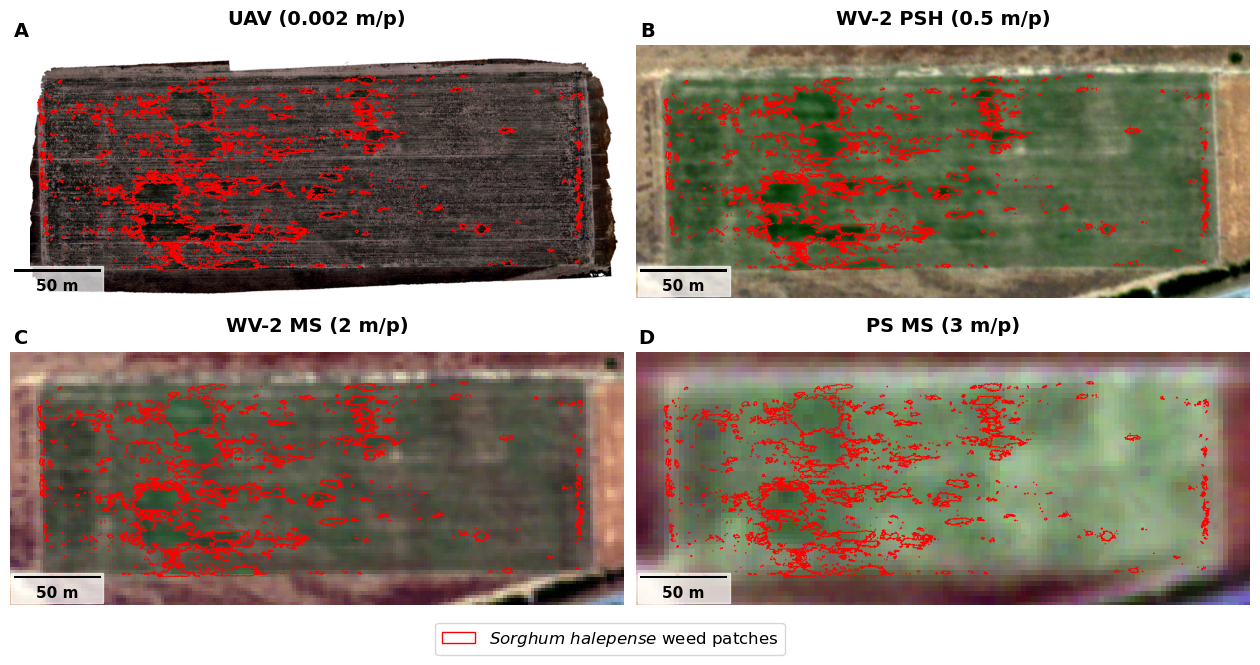

In [14]:
# Load and clean Planet / Drone Shapefile
gdf_pln = gpd.read_file(shp_pln)
gdf_pln_clean = gdf_pln[gdf_pln['Patch_size'] != 'no-sorgo'].copy()
gdf_pln_clean.geometry = gdf_pln_clean.geometry.make_valid()

# Load and clean WorldView-2 Shapefile
gdf_wv2 = gpd.read_file(shp_wv2)
gdf_wv2_clean = gdf_wv2[gdf_wv2['Patch_size'] != 'no-sorgo'].copy()
gdf_wv2_clean.geometry = gdf_wv2_clean.geometry.make_valid()

print(f"✅ Planet/Drone -> Retained: {len(gdf_pln_clean)}")
print(f"✅ WorldView-2 -> Retained: {len(gdf_wv2_clean)}")

# --- FIELD BOUNDARIES ---
gdf_limit_pln = gpd.read_file(shp_bounds)
gdf_limit_pln.geometry = gdf_limit_pln.geometry.make_valid()
gdf_limit_wv2 = gpd.read_file(shp_bounds_wv2)
gdf_limit_wv2.geometry = gdf_limit_wv2.geometry.make_valid()

def contrast_stretch_boa(arr, pmin=2, pmax=98):
    """Fast contrast stretching ignoring 0 values."""
    null_mask = arr == 0
    arr_out = np.zeros_like(arr, dtype=np.float32)
    for i in range(arr.shape[0]):
        band = arr[i]
        valid_band = band[band > 0]
        if len(valid_band) == 0: continue
        vmin, vmax = np.percentile(valid_band, (pmin, pmax))
        if vmax == vmin: vmax += 1e-5
        stretched_band = np.clip((band - vmin) / (vmax - vmin), 0, 1)
        arr_out[i] = stretched_band
    arr_out[null_mask] = 0
    return arr_out

def generate_ultra_fast_grid(image_dict, rotation_angle=-30, visual_buffer=15):
    first_config = list(image_dict.values())[0]
    gdf_limit_ref = first_config['gdf_limit']
    minx_ref, miny_ref, maxx_ref, maxy_ref = gdf_limit_ref.total_bounds
    cx_ref = (minx_ref + maxx_ref) / 2
    cy_ref = (miny_ref + maxy_ref) / 2
    
    # Rotate reference boundary and calculate dimensions
    gdf_limit_rot_ref = gdf_limit_ref.rotate(rotation_angle, origin=(cx_ref, cy_ref))
    rot_xmin_ref, rot_ymin_ref, rot_xmax_ref, rot_ymax_ref = gdf_limit_rot_ref.total_bounds
    zoom_width = (rot_xmax_ref - rot_xmin_ref) + 2 * visual_buffer
    zoom_height = (rot_ymax_ref - rot_ymin_ref) + 2 * visual_buffer
    aspect_ratio = zoom_width / zoom_height
    fig_width = 16
    
    # Set proportional height + space for title and legend (approx 1.2 inches)
    fig_height = (fig_width / aspect_ratio) + 1.2
    fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height), facecolor='white',
                             gridspec_kw={'hspace': 0.05, 'wspace': 0.02})
    axes = axes.flatten()
    
    red_patch = mpatches.Patch(edgecolor='red', facecolor='none', 
                               label=r'$\it{Sorghum\ halepense}$ weed patches', linewidth=1.0)
    subfigure_letters = ['A', 'B', 'C', 'D']
    
    for idx, (title, config) in enumerate(image_dict.items()):
        ax = axes[idx]
        raster_path = config['path']
        rgb_bands = config['rgb']
        gdf_patches = config['gdf_patches']
        gdf_limit = config['gdf_limit']
        
        # Calculate geographic centroid for vector and raster rotation
        minx, miny, maxx, maxy = gdf_limit.total_bounds
        cx = (minx + maxx) / 2
        cy = (miny + maxy) / 2
        
        # Read with an extended buffer to prevent clipping during rotation
        read_buffer = visual_buffer * 4
        p_xmin, p_ymin = minx - read_buffer, miny - read_buffer
        p_xmax, p_ymax = maxx + read_buffer, maxy + read_buffer
        
        with rasterio.open(raster_path) as src:
            window = from_bounds(p_xmin, p_ymin, p_xmax, p_ymax, src.transform)
            window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
            win_xmin, win_ymin, win_xmax, win_ymax = rasterio.windows.bounds(window, src.transform)
            win_w, win_h = int(window.width), int(window.height)
            
            MAX_DIM = 2000  
            if win_w > MAX_DIM or win_h > MAX_DIM:
                if win_w > win_h:
                    final_w = MAX_DIM
                    final_h = int(win_h * (MAX_DIM / win_w))
                else:
                    final_h = MAX_DIM
                    final_w = int(win_w * (MAX_DIM / win_h))
            else:
                final_h, final_w = win_h, win_w
                
            # Local spatial transform definition
            final_transform = rasterio.transform.from_bounds(win_xmin, win_ymin, win_xmax, win_ymax, final_w, final_h)
            
            # Read image data
            if win_w > MAX_DIM or win_h > MAX_DIM:
                out_image = src.read(
                    [int(b) for b in rgb_bands],
                    window=window,
                    out_shape=(len(rgb_bands), final_h, final_w),
                    resampling=Resampling.bilinear)
            else:
                out_image = src.read([int(b) for b in rgb_bands], window=window)
            bands, real_h, real_w = out_image.shape

            # Contrast stretching (BOA)
            stretched_arr = contrast_stretch_boa(out_image)
            img_plot = reshape_as_image(stretched_arr)

            # Calculate rotation center in pixels using the inverse transform
            col_c, row_c = ~final_transform * (cx, cy)
            
            # Rotate image array in pixel space
            M = cv2.getRotationMatrix2D((col_c, row_c), rotation_angle, 1.0)
            img_rot = cv2.warpAffine(img_plot, M, (real_w, real_h), flags=cv2.INTER_LINEAR, 
                                     borderMode=cv2.BORDER_CONSTANT, borderValue=(1.0, 1.0, 1.0))
            
            # Rotate vector geometries
            gdf_limit_rot = gdf_limit.rotate(rotation_angle, origin=(cx, cy))
            gdf_patches_rot = gdf_patches.rotate(rotation_angle, origin=(cx, cy))
            
            # Render rotated raster and boundaries
            ax.imshow(img_rot, extent=[win_xmin, win_xmax, win_ymin, win_ymax], origin='upper')
            gdf_limit_rot.plot(ax=ax, color='none', edgecolor='#00b4d8', linewidth=2.5, linestyle='--')
            gdf_patches_rot.plot(ax=ax, color='none', edgecolor='red', linewidth=0.6)
            
            rot_xmin, rot_ymin, rot_xmax, rot_ymax = gdf_limit_rot.total_bounds
            ax.set_xlim(rot_xmin - visual_buffer, rot_xmax + visual_buffer)
            ax.set_ylim(rot_ymin - visual_buffer, rot_ymax + visual_buffer)
            
            scale = ScaleBar(1, units="m", location="lower left", box_alpha=0.7, font_properties={'weight':'bold', 'size':11})
            ax.add_artist(scale)
            ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
            ax.axis('off')
            ax.text(0.03, 1.02, subfigure_letters[idx], transform=ax.transAxes, 
                    fontsize=14, fontweight='bold', va='bottom', ha='right')
            
    fig.legend(handles=[red_patch], loc='lower center', ncol=1, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.06))
    plt.tight_layout(rect=[0, 0.12, 1, 0.7])
    os.makedirs("08_resultados", exist_ok=True)
    output_path = "08_resultados/Cuadricula_Parcela_Enmascarada.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

images_to_process = {

    "UAV (0.002 m/p)": {
        "path": ortho_path, 
        "rgb": [1, 2, 3], 
        "gdf_patches": gdf_pln_clean,
        "gdf_limit": gdf_limit_pln},

    "WV-2 PSH (0.5 m/p)": {
        "path": pansharp_GS, 
        "rgb": [5, 3, 2], 
        "gdf_patches": gdf_wv2_clean,
        "gdf_limit": gdf_limit_wv2},

    "WV-2 MS (2 m/p)": {
        "path": out_ms_wv2, 
        "rgb": [5, 3, 2], 
        "gdf_patches": gdf_wv2_clean,
        "gdf_limit": gdf_limit_wv2},

    "PS MS (3 m/p)": {
        "path": out_pln, 
        "rgb": [6, 4, 2], 
        "gdf_patches": gdf_pln_clean,
        "gdf_limit": gdf_limit_pln} 
}

generate_ultra_fast_grid(images_to_process, rotation_angle=-30, visual_buffer=15)
